In [1]:
import os
import sys
import tempfile
import random
from glob import glob
from typing import List, Dict, Tuple, Optional
from PIL import Image

import monai
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter

from monai.data import Dataset, CacheDataset
from monai.transforms import (
    Compose,
    LoadImageD,
    EnsureChannelFirstD,
    ScaleIntensityRangeD,
    ResizeD,
    EnsureTypeD,
    RandFlipD,
    RandRotateD,
    RandAffineD,
    MapTransform,
)
from monai.networks.nets import densenet121
from monai.visualize import GradCAM

# For robust AUC
from sklearn.metrics import roc_auc_score

In [2]:
image_df = pd.read_csv("data/BBox_List_2017.csv")
patient_df = pd.read_csv("data/Data_Entry_2017.csv")

In [3]:
patient_df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [4]:
image_df.head()

,Image Index,Finding Label,Bbox [x,y,w,h],Unnamed: 6,Unnamed: 7,Unnamed: 8
0,00013118_008.png,Atelectasis,225.084746,547.019217,86.779661,79.186441,NaN,NaN,NaN
1,00014716_007.png,Atelectasis,686.101695,131.543498,185.491525,313.491525,NaN,NaN,NaN
2,00029817_009.png,Atelectasis,221.830508,317.053115,155.118644,216.949153,NaN,NaN,NaN
3,00014687_001.png,Atelectasis,726.237288,494.951420,141.016949,55.322034,NaN,NaN,NaN
4,00017877_001.png,Atelectasis,660.067797,569.780787,200.677966,78.101695,NaN,NaN,NaN


In [5]:
image_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Image Index    984 non-null    object 
 1   Finding Label  984 non-null    object 
 2   Bbox [x        984 non-null    float64
 3   y              984 non-null    float64
 4   w              984 non-null    float64
 5   h]             984 non-null    float64
 6   Unnamed: 6     0 non-null      float64
 7   Unnamed: 7     0 non-null      float64
 8   Unnamed: 8     0 non-null      float64
dtypes: float64(7), object(2)
memory usage: 69.3+ KB


In [6]:
patient_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112120 entries, 0 to 112119
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Image Index                  112120 non-null  object 
 1   Finding Labels               112120 non-null  object 
 2   Follow-up #                  112120 non-null  int64  
 3   Patient ID                   112120 non-null  int64  
 4   Patient Age                  112120 non-null  int64  
 5   Patient Gender               112120 non-null  object 
 6   View Position                112120 non-null  object 
 7   OriginalImage[Width          112120 non-null  int64  
 8   Height]                      112120 non-null  int64  
 9   OriginalImagePixelSpacing[x  112120 non-null  float64
 10  y]                           112120 non-null  float64
 11  Unnamed: 11                  0 non-null       float64
dtypes: float64(3), int64(5), object(4)
memory usage: 10.3+ MB


In [7]:
all_image_paths = {os.path.basename(x): x for x in 
                   glob(os.path.join('data',  'images*', '*', '*.png'))}

patient_df['image_path'] = patient_df['Image Index'].map(all_image_paths.get)

In [8]:
# patient_df = (
#     patient_df
#     .assign(labels=patient_df["Finding Labels"].str.split("|"))
#     .explode("labels")
# )

patient_df.rename(columns={"Finding Labels":"labels"}, inplace=True)

In [9]:
patient_df.drop(["Unnamed: 11"], axis=1, inplace=True)
image_df.drop(["Unnamed: 6", "Unnamed: 7", "Unnamed: 8"], axis=1, inplace=True)

patient_df.shape, image_df.shape

((112120, 12), (984, 6))

In [10]:
patient_df.rename(columns={"OriginalImage[Width": "OriginalImage[Width]", 
                           "Height]":"OriginalImage[Height]", "OriginalImagePixelSpacing[x":"OriginalImagePixelSpacing[x]",
                           "y]":"OriginalImagePixelSpacing[y]"}, inplace=True)

image_df.rename(columns={"Bbox [x":"Bbox [x]", "y":"Bbox [y]", "w":"Bbox [w]", "h]":"Bbox [h]",
                          "Finding Label":"labels"}, inplace=True)


In [11]:
df_merged = pd.merge(
    image_df,
    patient_df,
    on="Image Index",
    # how="left"   # inner, left, right, outer
)
df_merged.head()

,Image Index,labels_x,Bbox [x],Bbox [y],Bbox [w],Bbox [h],labels_y,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width],OriginalImage[Height],OriginalImagePixelSpacing[x],OriginalImagePixelSpacing[y],image_path
0,00013118_008.png,Atelectasis,225.084746,547.019217,86.779661,79.186441,Atelectasis,8,13118,69,M,PA,2992,2991,0.143,0.143,data/images_006/images/00013118_008.png
1,00014716_007.png,Atelectasis,686.101695,131.543498,185.491525,313.491525,Atelectasis|Effusion|Mass,7,14716,53,M,AP,3056,2544,0.139,0.139,data/images_007/images/00014716_007.png
2,00029817_009.png,Atelectasis,221.830508,317.053115,155.118644,216.949153,Atelectasis,9,29817,67,F,AP,3056,2544,0.139,0.139,data/images_012/images/00029817_009.png
3,00014687_001.png,Atelectasis,726.237288,494.951420,141.016949,55.322034,Atelectasis|Cardiomegaly|Consolidation,1,14687,51,M,AP,2500,2048,0.168,0.168,data/images_007/images/00014687_001.png
4,00017877_001.png,Atelectasis,660.067797,569.780787,200.677966,78.101695,Atelectasis,1,17877,75,F,AP,2500,2048,0.168,0.168,data/images_008/images/00017877_001.png


In [12]:
df_merged.loc[df_merged["labels_x"] == "Infiltrate", "labels_x"] = "Infiltration"

In [13]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Image Index                   984 non-null    object 
 1   labels_x                      984 non-null    object 
 2   Bbox [x]                      984 non-null    float64
 3   Bbox [y]                      984 non-null    float64
 4   Bbox [w]                      984 non-null    float64
 5   Bbox [h]                      984 non-null    float64
 6   labels_y                      984 non-null    object 
 7   Follow-up #                   984 non-null    int64  
 8   Patient ID                    984 non-null    int64  
 9   Patient Age                   984 non-null    int64  
 10  Patient Gender                984 non-null    object 
 11  View Position                 984 non-null    object 
 12  OriginalImage[Width]          984 non-null    int64  
 13  Origi

In [14]:
patient_df["labels"].value_counts()

labels
No Finding                                                         60361
Infiltration                                                        9547
Atelectasis                                                         4215
Effusion                                                            3955
Nodule                                                              2705
                                                                   ...  
Atelectasis|Consolidation|Edema|Effusion|Infiltration|Pneumonia        1
Atelectasis|Consolidation|Effusion|Emphysema|Mass|Pneumothorax         1
Cardiomegaly|Effusion|Pleural_Thickening|Pneumothorax                  1
Edema|Infiltration|Pneumothorax                                        1
Atelectasis|Consolidation|Mass|Pleural_Thickening|Pneumothorax         1
Name: count, Length: 836, dtype: int64

In [15]:
patient_df = patient_df[~patient_df["labels"].str.contains('Hernia')]

In [ ]:
patient_df = pd.concat([patient_df[patient_df["labels"]!="No Finding"], 
patient_df[patient_df["labels"]=="No Finding"].sample(n=6000)], ignore_index=True)

patient_df.shape

(57532, 12)

In [ ]:
# DATA_PATH = "data/Patient_data.csv"
# patient_df.to_csv(DATA_PATH, index=False)

In [18]:
patient_labels = (
    patient_df
    .assign(labels=patient_df["labels"].str.split("|"))
    .explode("labels")
)
patient_labels["labels"].value_counts()

labels
Infiltration          19861
Effusion              13296
Atelectasis           11519
Nodule                 6321
No Finding             6000
Mass                   5757
Pneumothorax           5293
Consolidation          4663
Pleural_Thickening     3377
Cardiomegaly           2769
Emphysema              2512
Edema                  2300
Fibrosis               1678
Pneumonia              1428
Name: count, dtype: int64

In [19]:
LABELS = [
    "No Finding",
    "Infiltration",
    "Effusion",
    "Atelectasis",
    "Nodule",
    "Mass",
    "Pneumothorax",
    "Consolidation",
    "Pleural_Thickening",
    "Cardiomegaly",
    "Emphysema",
    "Edema",
    "Fibrosis",
    "Pneumonia"
]

patient_df_list = []
for col in LABELS:
    patient_df_list.append(patient_df[patient_df["labels"].str.contains(col)].sample(1420))

In [20]:
patient_df_sampled = pd.concat(patient_df_list)
patient_df_sampled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19880 entries, 53096 to 50221
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Image Index                   19880 non-null  object 
 1   labels                        19880 non-null  object 
 2   Follow-up #                   19880 non-null  int64  
 3   Patient ID                    19880 non-null  int64  
 4   Patient Age                   19880 non-null  int64  
 5   Patient Gender                19880 non-null  object 
 6   View Position                 19880 non-null  object 
 7   OriginalImage[Width]          19880 non-null  int64  
 8   OriginalImage[Height]         19880 non-null  int64  
 9   OriginalImagePixelSpacing[x]  19880 non-null  float64
 10  OriginalImagePixelSpacing[y]  19880 non-null  float64
 11  image_path                    19880 non-null  object 
dtypes: float64(2), int64(5), object(5)
memory usage: 2.0+ MB


In [23]:
# DATA_PATH = "data/Patient_data.csv"
# patient_df_sampled.to_csv(DATA_PATH, index=False)

In [2]:
# -----------------------------
# 0) Label setup (15 classes)
# -----------------------------
LABELS = [
    "No Finding",
    "Infiltration",
    "Effusion",
    "Atelectasis",
    "Nodule",
    "Mass",
    "Pneumothorax",
    "Consolidation",
    "Pleural_Thickening",
    "Cardiomegaly",
    "Emphysema",
    "Edema",
    "Fibrosis",
    "Pneumonia"
]
label_to_idx = {l: i for i, l in enumerate(LABELS)}
NUM_CLASSES = len(LABELS)

In [3]:
# -----------------------------
# 1) Utilities: labels + split
# -----------------------------
def multilabel_to_multihot(label_str: str) -> np.ndarray:
    """
    Converts pipe-separated multi-label string -> multi-hot float vector.
    Robust "No Finding" handling:
      - if empty/NaN -> No Finding = 1
      - if only "No Finding" -> No Finding = 1
      - if any disease labels present -> No Finding = 0
    """
    y = np.zeros(NUM_CLASSES, dtype=np.float32)

    if pd.isna(label_str) or str(label_str).strip() == "":
        y[label_to_idx["No Finding"]] = 1.0
        return y

    parts = [p.strip() for p in str(label_str).split("|") if p.strip()]
    # collect known disease labels excluding No Finding
    known_diseases = [p for p in parts if p in label_to_idx and p != "No Finding"]

    if len(known_diseases) == 0:
        # if there are no disease labels, treat as No Finding
        y[label_to_idx["No Finding"]] = 1.0
        return y

    for p in known_diseases:
        y[label_to_idx[p]] = 1.0

    # ensure No Finding = 0 when any disease label exists
    y[label_to_idx["No Finding"]] = 0.0
    return y


def make_items_from_csv(csv_path: str) -> List[Dict]:
    df = pd.read_csv(csv_path)
    df = df.sample(frac=1)
    if "image_path" not in df.columns or "labels" not in df.columns:
        raise ValueError("CSV must have columns: image_path, labels")

    items = []
    for _, row in df.iterrows():
        img_path = str(row["image_path"])
        y = multilabel_to_multihot(row["labels"])
        items.append({"image": img_path, "label": y})
    return items


def train_val_split(
    items: List[Dict], val_frac: float = 0.1, seed: int = 42
) -> Tuple[List[Dict], List[Dict]]:
    rng = random.Random(seed)
    rng.shuffle(items)
    n_val = max(1, int(len(items) * val_frac))
    return items[n_val:], items[:n_val]

In [4]:
multilabel_to_multihot("Atelectasis|Consolidation|Edema|Effusion|Infiltration|Pneumonia")

array([0., 1., 1., 1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 1.],
      dtype=float32)

In [5]:
# -----------------------------
# 2) MONAI transform helpers
# -----------------------------
class ToGrayscaleD(MapTransform):
    """
    Ensures image is 1-channel. If loaded as RGB/multi-channel, converts by mean over channels.
    Expects channel-first [C,H,W].
    """

    def __call__(self, data):
        d = dict(data)
        x = d["image"]
        # x can be numpy or torch
        c = x.shape[0]
        if c > 1:
            x = x.mean(axis=0, keepdims=True)
        d["image"] = x
        return d


def get_transforms(img_size=(320, 320)):
    # Deterministic preprocessing (safe to cache)
    pre_tfms = Compose(
        [
            LoadImageD(keys="image", image_only=True),
            EnsureChannelFirstD(keys="image"),  # -> [C,H,W] or [1,H,W]
            ToGrayscaleD(keys="image"),
            # If your images are already float [0..1], adjust a_min/a_max accordingly
            ScaleIntensityRangeD(
                keys="image", a_min=0, a_max=255, b_min=0.0, b_max=1.0, clip=True
            ),
            ResizeD(keys="image", spatial_size=img_size),
            EnsureTypeD(keys=("image", "label")),
        ]
    )

    # Random augmentations (DO NOT cache these)
    aug_tfms = Compose(
        [
            RandFlipD(keys="image", prob=0.5, spatial_axis=1),
            RandRotateD(keys="image", range_x=np.pi / 36, prob=0.3),
            RandAffineD(keys="image", prob=0.2, translate_range=(10, 10)),
            EnsureTypeD(keys=("image", "label")),
        ]
    )

    # Validation: deterministic only
    val_tfms = pre_tfms
    return pre_tfms, aug_tfms, val_tfms


def build_loaders(
    csv_path: str,
    batch_size: int = 32,
    num_workers: int = 8,
    cache_rate: float = 0.2,
    val_frac: float = 0.1,
    seed: int = 42,
    img_size=(320, 320),
):
    items = make_items_from_csv(csv_path)
    train_items, val_items = train_val_split(items, val_frac=val_frac, seed=seed)

    pre_tfms, aug_tfms, val_tfms = get_transforms(img_size=img_size)

    # Cache only deterministic preprocessing
    train_cached = CacheDataset(
        data=train_items,
        transform=pre_tfms,
        cache_rate=cache_rate,
        num_workers=num_workers,
    )
    # Apply augmentation after cache
    train_ds = Dataset(data=train_cached, transform=aug_tfms)

    # Val can be cached too (deterministic)
    val_ds = CacheDataset(
        data=val_items,
        transform=val_tfms,
        cache_rate=min(1.0, cache_rate),
        num_workers=num_workers,
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
    )

    return train_loader, val_loader, train_items, val_items


In [6]:
# -----------------------------
# 3) Metrics: robust per-class AUC
# -----------------------------
def compute_macro_auc(
    y_true: np.ndarray, y_prob: np.ndarray, eps: float = 1e-8
) -> Tuple[float, np.ndarray, np.ndarray]:
    """
    y_true: [N,C] multi-hot (0/1)
    y_prob: [N,C] probabilities in [0,1]
    Returns:
      macro_auc (mean over valid classes),
      per_class_auc [C] with NaN for invalid classes,
      valid_mask [C] bool (True = class used)
    """
    C = y_true.shape[1]
    per_auc = np.full((C,), np.nan, dtype=np.float32)
    valid = np.zeros((C,), dtype=bool)

    for c in range(C):
        yt = y_true[:, c]
        yp = y_prob[:, c]
        # Need both positive and negative samples for ROC AUC
        if yt.max() == yt.min():
            continue
        try:
            per_auc[c] = roc_auc_score(yt, yp)
            valid[c] = True
        except Exception:
            # keep NaN
            pass

    if valid.any():
        macro = float(np.nanmean(per_auc))
    else:
        macro = float("nan")
    return macro, per_auc, valid


# -----------------------------
# 4) Loss: pos_weight for imbalance
# -----------------------------
def compute_pos_weight_from_items(train_items: List[Dict]) -> torch.Tensor:
    """
    pos_weight for BCEWithLogitsLoss:
      pos_weight[c] = (#neg[c] / #pos[c])
    """
    y = np.stack([it["label"] for it in train_items], axis=0)  # [N,C]
    pos = y.sum(axis=0)  # [C]
    neg = y.shape[0] - pos
    # pos_weight = np.sqrt(neg / (pos + 1e-5))
    pos_weight = neg / (pos + 1e-8)
    return torch.tensor(pos_weight, dtype=torch.float32)

In [7]:
csv_path = "data/Patient_data.csv"
out_path = "outputs/checkpoints/best_cxr_multilabel.pt"
epochs = 10
batch_size = 32
lr = 1e-4
num_workers = 8
cache_rate = 0.3
val_frac = 0.1
seed = 43
img_size =(320, 320)
amp = True
use_pos_weight = True

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [9]:
train_loader, val_loader, train_items, val_items = build_loaders(
    csv_path=csv_path,
    batch_size=batch_size,
    num_workers=num_workers,
    cache_rate=cache_rate,
    val_frac=val_frac,
    seed=seed,
    img_size=img_size,
)

Loading dataset:   3%|▎         | 429/15533 [00:01<01:00, 249.18it/s]

Loading dataset: 100%|██████████| 1725/1725 [00:07<00:00, 227.71it/s]


In [10]:
for batch in train_loader:
    print(batch["image"].shape)
    break

torch.Size([32, 1, 320, 320])


In [59]:
model = densenet121(spatial_dims=2, in_channels=1, out_channels=NUM_CLASSES).to(
        device
    )

In [60]:
from torchinfo import summary

# A batch size of 1 is common for just getting the summary
input_size = (1, 1, 320, 320)

# Print the model summary
summary(model, input_size=input_size)

Layer (type:depth-idx)                        Output Shape              Param #
DenseNet121                                   [1, 14]                   --
├─Sequential: 1-1                             [1, 1024, 10, 10]         --
│    └─Conv2d: 2-1                            [1, 64, 160, 160]         3,136
│    └─BatchNorm2d: 2-2                       [1, 64, 160, 160]         128
│    └─ReLU: 2-3                              [1, 64, 160, 160]         --
│    └─MaxPool2d: 2-4                         [1, 64, 80, 80]           --
│    └─_DenseBlock: 2-5                       [1, 256, 80, 80]          --
│    │    └─_DenseLayer: 3-1                  [1, 96, 80, 80]           45,440
│    │    └─_DenseLayer: 3-2                  [1, 128, 80, 80]          49,600
│    │    └─_DenseLayer: 3-3                  [1, 160, 80, 80]          53,760
│    │    └─_DenseLayer: 3-4                  [1, 192, 80, 80]          57,920
│    │    └─_DenseLayer: 3-5                  [1, 224, 80, 80]          62,

In [61]:
if use_pos_weight:
    pos_weight = compute_pos_weight_from_items(train_items).to(device)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
else:
    loss_fn = nn.BCEWithLogitsLoss()

opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
scaler = torch.amp.GradScaler(enabled=(amp and device.type == "cuda"), device=device)

In [62]:
pos_weight

tensor([ 8.5147,  1.8920,  3.3377,  3.9907,  8.1016,  9.0153,  9.8302, 11.3489,
        15.9823, 19.7781, 21.9517, 24.1843, 33.4734, 39.4840], device='cuda:0')

In [63]:
best_macro_auc = -1.0

for epoch in range(1, epochs + 1):
    # ---- train ----
    model.train()
    running_loss = 0.0
    n_seen = 0

    for batch in train_loader:
        x = batch["image"].to(device)  # [B,1,H,W]
        y = batch["label"].to(device)  # [B,C] float

        opt.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda",enabled=(amp and device.type == "cuda")):
            logits = model(x)  # [B,C]
            loss = loss_fn(logits, y)

        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()

        running_loss += loss.item() * x.size(0)
        n_seen += x.size(0)

    train_loss = running_loss / max(1, n_seen)

    # ---- validate ----
    model.eval()
    probs_all = []
    y_all = []
    with torch.no_grad():
        for batch in val_loader:
            x = batch["image"].to(device)
            y = batch["label"].to(device)
            with torch.amp.autocast("cuda",enabled=(amp and device.type == "cuda")):
                logits = model(x)
                probs = torch.sigmoid(logits)

            probs_all.append(probs.detach().cpu())
            y_all.append(y.detach().cpu())

    probs_all = torch.cat(probs_all, dim=0).numpy()
    y_all = torch.cat(y_all, dim=0).numpy()

    macro_auc, per_auc, valid_mask = compute_macro_auc(y_all, probs_all)

    valid_count = int(valid_mask.sum())
    # show a short per-class summary for the rare labels
    hernia_auc = per_auc[label_to_idx["Pneumonia"]]
    nf_auc = per_auc[label_to_idx["No Finding"]]

    print(
        f"Epoch {epoch:03d}/{epochs} | "
        f"train_loss={train_loss:.4f} | "
        f"val_macro_auc={macro_auc:.4f} (valid_classes={valid_count}/{NUM_CLASSES}) | "
        f"AUC(NoFinding)={nf_auc if not np.isnan(nf_auc) else 'NA'} | "
        f"AUC(Pneumonia)={hernia_auc if not np.isnan(hernia_auc) else 'NA'}"
    )

    if not np.isnan(macro_auc) and macro_auc > best_macro_auc:
        best_macro_auc = macro_auc
        torch.save(
            {
                "model": model.state_dict(),
                "labels": LABELS,
                "img_size": img_size,
                "csv": os.path.abspath(csv_path),
            },
            out_path,
        )
        print(f"  ✅ Saved best checkpoint: {out_path} (macro_auc={best_macro_auc:.4f})")

print("Training done.")


Epoch 001/10 | train_loss=1.1979 | val_macro_auc=0.6430 (valid_classes=14/14) | AUC(NoFinding)=0.6717946529388428 | AUC(Pneumonia)=0.5613727569580078
  ✅ Saved best checkpoint: outputs/checkpoints/best_cxr_multilabel.pt (macro_auc=0.6430)
Epoch 002/10 | train_loss=1.1716 | val_macro_auc=0.6610 (valid_classes=14/14) | AUC(NoFinding)=0.7082454562187195 | AUC(Pneumonia)=0.5819189548492432
  ✅ Saved best checkpoint: outputs/checkpoints/best_cxr_multilabel.pt (macro_auc=0.6610)
Epoch 003/10 | train_loss=1.1575 | val_macro_auc=0.6702 (valid_classes=14/14) | AUC(NoFinding)=0.724287211894989 | AUC(Pneumonia)=0.6029729247093201
  ✅ Saved best checkpoint: outputs/checkpoints/best_cxr_multilabel.pt (macro_auc=0.6702)
Epoch 004/10 | train_loss=1.1443 | val_macro_auc=0.6802 (valid_classes=14/14) | AUC(NoFinding)=0.7337878346443176 | AUC(Pneumonia)=0.6210598349571228
  ✅ Saved best checkpoint: outputs/checkpoints/best_cxr_multilabel.pt (macro_auc=0.6802)
Epoch 005/10 | train_loss=1.1325 | val_macro_

In [11]:
# -----------------------------
# 6) Inference + Grad-CAM + overlay plotting
# -----------------------------

def disable_inplace_relu(m):
    for mod in m.modules():
        if isinstance(mod, nn.ReLU):
            mod.inplace = False

def load_checkpoint(ckpt_path: str, device=None):
    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
    ckpt = torch.load(ckpt_path, map_location=device)
    model = densenet121(spatial_dims=2, in_channels=1, out_channels=NUM_CLASSES).to(
        device
    )
    model.load_state_dict(ckpt["model"])
    disable_inplace_relu(model)
    model.eval()
    img_size = tuple(ckpt.get("img_size", (320, 320)))
    return model, ckpt.get("labels", LABELS), img_size, device


def build_single_image_preprocess(img_size=(320, 320)):
    # Same deterministic preprocessing used in training/val
    pre_tfms = Compose(
        [
            LoadImageD(keys="image", image_only=True),
            EnsureChannelFirstD(keys="image"),
            ToGrayscaleD(keys="image"),
            ScaleIntensityRangeD(
                keys="image", a_min=0, a_max=255, b_min=0.0, b_max=1.0, clip=True
            ),
            ResizeD(keys="image", spatial_size=img_size),
            EnsureTypeD(keys="image", track_meta=False),
        ]
    )
    return pre_tfms


def infer_with_gradcam(
    model: torch.nn.Module,
    image_path: str,
    class_idx: int,
    img_size=(320, 320),
    target_layers: str = "features",
):
    """
    Returns:
      probs: [C] float numpy
      cam:   [h,w] float numpy (0..1), typically lower-res than input
      img:   [H,W] float numpy (0..1) preprocessed image
    """
    device = next(model.parameters()).device
    pre = build_single_image_preprocess(img_size=img_size)

    sample = {"image": image_path}
    x = pre(sample)["image"]  # [1,H,W] torch tensor
    x = x.unsqueeze(0).to(device)  # [1,1,H,W]

    # Probabilities (no-grad)
    with torch.no_grad():
        logits = model(x)
        probs = torch.sigmoid(logits)[0].detach().cpu().numpy()

    # Grad-CAM needs gradients (do NOT wrap in torch.no_grad)
    cam_gen = GradCAM(nn_module=model, target_layers=target_layers)
    cam = cam_gen(x, class_idx=class_idx)  # [1,1,h,w]
    cam = cam[0, 0].detach().cpu().numpy()
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    img = x[0, 0].detach().cpu().numpy()  # [H,W] 0..1
    return probs, cam, img


def overlay_cam(img: np.ndarray, cam: np.ndarray, alpha: float = 0.35) -> np.ndarray:
    """
    img: [H,W] float 0..1
    cam: [h,w] float 0..1
    output: [H,W] float 0..1 (simple blend; for nicer visuals use colormap overlay)
    """
    if cam.shape != img.shape:
        cam_t = torch.tensor(cam)[None, None, ...]
        cam_rs = torch.nn.functional.interpolate(
            cam_t, size=img.shape, mode="bilinear", align_corners=False
        )[0, 0].numpy()
    else:
        cam_rs = cam

    out = (1 - alpha) * img + alpha * cam_rs
    return np.clip(out, 0.0, 1.0)


def visualize_gradcam(image_path: str, ckpt_path: str, class_name: str):
    import matplotlib.pyplot as plt

    model, labels, img_size, device = load_checkpoint(ckpt_path)
    if class_name not in label_to_idx:
        raise ValueError(f"class_name must be one of: {labels}")

    class_idx = label_to_idx[class_name]
    probs, cam, img = infer_with_gradcam(
        model=model,
        image_path=image_path,
        class_idx=class_idx,
        img_size=img_size,
        target_layers="features",
    )

    blended = overlay_cam(img, cam, alpha=0.35)
    # probs = np.where(probs > 0.6, 1, 0)
    topk = np.argsort(-probs)[:5]
    print("Top-5 predicted labels:")
    for i in topk:
        print(f"  {labels[i]:>20s}: {probs[i]:.4f}")

    plt.figure()
    plt.title(f"Grad-CAM blend for: {class_name} (p={probs[class_idx]:.3f})")
    plt.imshow(blended, cmap="gray")
    plt.axis("off")
    plt.show()

    # Optional: show CAM heatmap itself
    plt.figure()
    plt.title("Grad-CAM heatmap")
    plt.imshow(img, cmap="gray")
    plt.imshow(
        torch.nn.functional.interpolate(
            torch.tensor(cam)[None, None, ...],
            size=img.shape,
            mode="bilinear",
            align_corners=False,
        )[0, 0].numpy(),
        cmap="jet",
        alpha=0.4,
    )
    plt.axis("off")
    plt.show()



In [12]:
df_merged.head()

NameError: name 'df_merged' is not defined

In [66]:
df_merged["labels_x"].value_counts()

labels_x
Atelectasis     180
Effusion        153
Cardiomegaly    146
Infiltration    123
Pneumonia       120
Pneumothorax     98
Mass             85
Nodule           79
Name: count, dtype: int64

In [67]:
tmp_df = df_merged[df_merged["labels_x"]=="Atelectasis"]
tmp_df.shape

(180, 17)

True Label: Atelectasis|Nodule|Mass 

Top-5 predicted labels:
                 Edema: 0.6912
         Consolidation: 0.6782
           Atelectasis: 0.6320
          Infiltration: 0.5762
              Effusion: 0.5541


Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


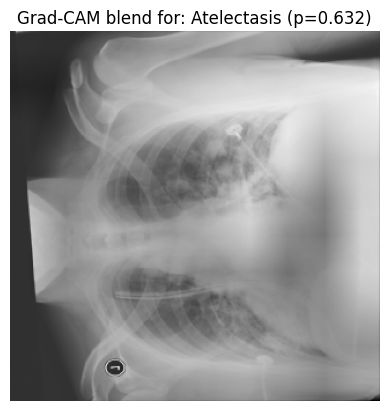

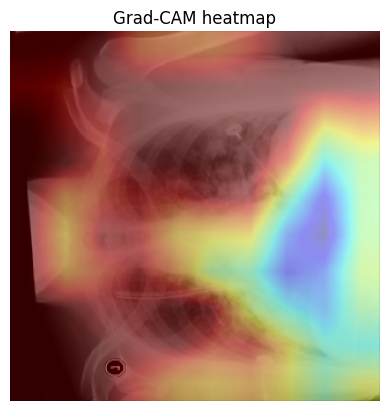

In [74]:
i=96

img_path = tmp_df.iloc[i]["image_path"]
cls_label = tmp_df.iloc[i]["labels_x"]
print("True Label:", tmp_df.iloc[i]["labels_y"], "\n")
visualize_gradcam(
        image_path=img_path,
        ckpt_path=out_path,
        class_name=cls_label,
    )

In [13]:
# ---- validate ----
model, labels, img_size, device = load_checkpoint(out_path)
model.eval()
probs_all = []
y_all = []
with torch.no_grad():
    for batch in val_loader:
        x = batch["image"].to(device)
        y = batch["label"].to(device)
        with torch.amp.autocast("cuda",enabled=(amp and device.type == "cuda")):
            logits = model(x)
            probs = torch.sigmoid(logits)

        probs_all.append(probs.detach().cpu())
        y_all.append(y.detach().cpu())

probs_all = torch.cat(probs_all, dim=0).numpy()
y_all = torch.cat(y_all, dim=0).numpy()

In [14]:
y_all.shape, probs_all.shape

((5753, 14), (5753, 14))

In [15]:
probs_all = np.where(probs_all > 0.6, 1, 0)

In [16]:
for y_true_i, y_pred_i in zip(y_all, probs_all):
    print(np.nonzero(y_true_i), np.nonzero(y_pred_i))
    break

(array([1]),) (array([ 1,  4, 11, 13]),)


In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_all, probs_all, target_names=labels, zero_division=0))

                    precision    recall  f1-score   support

        No Finding       0.25      0.58      0.35       558
      Infiltration       0.50      0.31      0.38      1957
          Effusion       0.41      0.52      0.46      1359
       Atelectasis       0.33      0.41      0.36      1144
            Nodule       0.26      0.16      0.20       632
              Mass       0.21      0.20      0.21       587
      Pneumothorax       0.23      0.52      0.32       512
     Consolidation       0.16      0.51      0.24       470
Pleural_Thickening       0.11      0.27      0.16       328
      Cardiomegaly       0.14      0.57      0.23       277
         Emphysema       0.12      0.51      0.19       256
             Edema       0.15      0.68      0.24       244
          Fibrosis       0.08      0.38      0.13       176
         Pneumonia       0.04      0.21      0.07       149

         micro avg       0.23      0.40      0.29      8649
         macro avg       0.21      0.4

In [18]:
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, f1_score, roc_curve, precision_recall_curve

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

@torch.no_grad()
def collect_val_outputs(model, val_loader, device):
    model.eval()
    probs_all, y_all = [], []
    for batch in val_loader:
        x = batch["image"].to(device)
        y = batch["label"].cpu().numpy()
        logits = model(x).detach().cpu().numpy()
        probs = sigmoid(logits)
        probs_all.append(probs)
        y_all.append(y)
    return np.concatenate(probs_all, axis=0), np.concatenate(y_all, axis=0)

def per_class_metrics_and_thresholds(y_true, y_prob, labels, method="f1", default_thr=0.5):
    """
    method:
      - "f1": choose threshold maximizing F1 on validation (common for improving report)
      - "youden": choose threshold maximizing (tpr - fpr) from ROC
      - "pr_f1": same as f1 but uses PR curve thresholds (often smoother)
    """
    C = y_true.shape[1]
    auc = np.full(C, np.nan, dtype=np.float32)
    ap  = np.full(C, np.nan, dtype=np.float32)
    thr = np.full(C, default_thr, dtype=np.float32)
    valid = np.zeros(C, dtype=bool)

    for c in range(C):
        yt = y_true[:, c]
        yp = y_prob[:, c]
        if yt.max() == yt.min():  # all 0 or all 1 -> cannot compute meaningful curves
            continue

        valid[c] = True
        auc[c] = roc_auc_score(yt, yp)
        ap[c]  = average_precision_score(yt, yp)

        if method == "youden":
            fpr, tpr, thresholds = roc_curve(yt, yp)
            j = tpr - fpr
            thr[c] = thresholds[np.argmax(j)]

        elif method in ("f1", "pr_f1"):
            # Sweep thresholds to maximize F1
            if method == "pr_f1":
                p, r, thresholds = precision_recall_curve(yt, yp)
                # precision_recall_curve returns thresholds of length-1 of p/r
                # We'll compute F1 for those points
                f1 = (2 * p[:-1] * r[:-1]) / (p[:-1] + r[:-1] + 1e-12)
                thr[c] = thresholds[np.argmax(f1)]
            else:
                # dense sweep 0..1
                candidates = np.linspace(0.01, 0.99, 99)
                f1s = [f1_score(yt, (yp >= t).astype(int), zero_division=0) for t in candidates]
                thr[c] = candidates[int(np.argmax(f1s))]

        else:
            raise ValueError("method must be one of: f1, youden, pr_f1")

    return auc, ap, thr, valid

def apply_thresholds(y_prob, thresholds):
    return (y_prob >= thresholds[None, :]).astype(np.int32)

def enforce_topk(y_prob, k=1, min_thr=None):
    """
    Ensures at least k labels predicted per sample (useful to avoid 'no predicted labels' warnings).
    If min_thr is set, we only apply top-k when no label exceeds min_thr.
    """
    y_pred = np.zeros_like(y_prob, dtype=np.int32)
    if min_thr is None:
        idx = np.argsort(-y_prob, axis=1)[:, :k]
        rows = np.arange(y_prob.shape[0])[:, None]
        y_pred[rows, idx] = 1
    else:
        # if any above min_thr -> threshold normally, else top-k
        thr_pred = (y_prob >= min_thr).astype(np.int32)
        need = thr_pred.sum(axis=1) == 0
        y_pred[:] = thr_pred
        if np.any(need):
            idx = np.argsort(-y_prob[need], axis=1)[:, :k]
            rows = np.arange(idx.shape[0])[:, None]
            y_pred_need = np.zeros_like(y_prob[need], dtype=np.int32)
            y_pred_need[rows, idx] = 1
            y_pred[need] = y_pred_need
    return y_pred

In [19]:
# ---------------------------
# Example usage
# ---------------------------
probs_val, y_val = collect_val_outputs(model, val_loader, device)

# Compute thresholds (try method="youden" first for clinically balanced operating point)
auc, ap, thr, valid = per_class_metrics_and_thresholds(y_val, probs_val, labels, method="youden")

# Optional: neutralize No Finding thresholding
thr[label_to_idx["No Finding"]] = 0.5

y_pred = apply_thresholds(probs_val, thr)
print(classification_report(y_val, y_pred, target_names=labels, zero_division=0))

# Print summary
print("macro ROC-AUC:", np.nanmean(auc))
print("macro PR-AUC :", np.nanmean(ap))

                    precision    recall  f1-score   support

        No Finding       0.20      0.71      0.31       558
      Infiltration       0.45      0.55      0.50      1957
          Effusion       0.37      0.74      0.49      1359
       Atelectasis       0.28      0.77      0.41      1144
            Nodule       0.17      0.64      0.27       632
              Mass       0.16      0.54      0.25       587
      Pneumothorax       0.20      0.65      0.30       512
     Consolidation       0.14      0.68      0.23       470
Pleural_Thickening       0.09      0.67      0.16       328
      Cardiomegaly       0.12      0.69      0.20       277
         Emphysema       0.09      0.69      0.17       256
             Edema       0.11      0.83      0.20       244
          Fibrosis       0.07      0.68      0.12       176
         Pneumonia       0.04      0.64      0.07       149

         micro avg       0.19      0.66      0.29      8649
         macro avg       0.18      0.6

Text(0, 0.5, 'True Positive Rate')

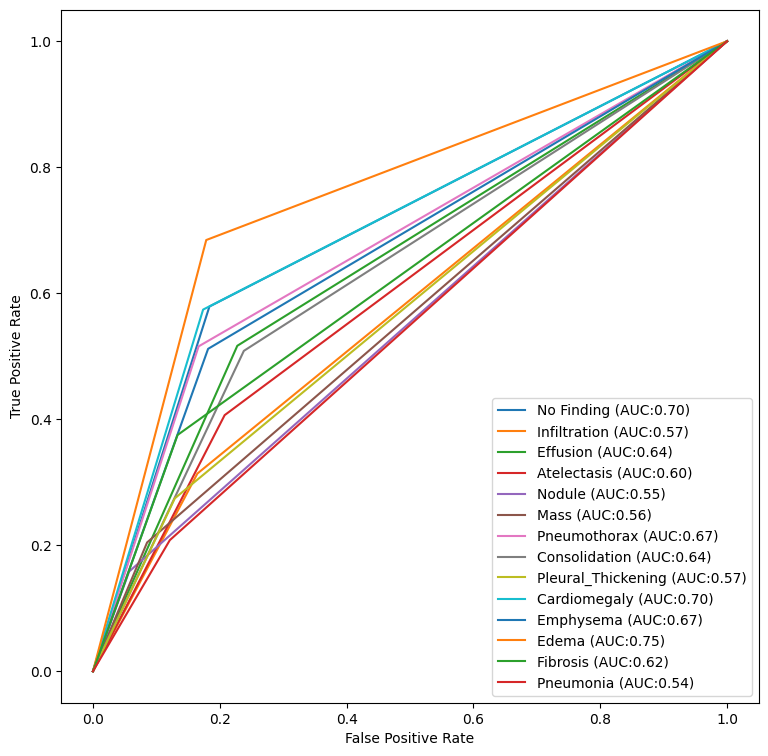

In [21]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fig, c_ax = plt.subplots(1,1, figsize = (9, 9))
for (idx, c_label) in enumerate(LABELS):
    fpr, tpr, thresholds = roc_curve(y_all[:,idx].astype(int), probs_all[:,idx])
    c_ax.plot(fpr, tpr, label = '%s (AUC:%0.2f)'  % (c_label, auc(fpr, tpr)))
c_ax.legend()
c_ax.set_xlabel('False Positive Rate')
c_ax.set_ylabel('True Positive Rate')